# Project: Analyzing the Relationship Between Airbnb Listings and CTA Rail Transit in Chicago

## 1. Introduction

### 1.1 Project Overview
In this GGIS 407 project, I explore the spatial relationship between Airbnb rental properties and public transit infrastructure in Chicago, Illinois. Specifically, I examine how proximity to CTA "L" train stations influences the distribution, pricing, and characteristics of Airbnb listings across the city.

### 1.2 Research Question
This project addresses four specific questions:

* **Distance Measurement**: How far are Airbnb listings from the nearest CTA rail station?

* **Walkability Analysis**: What percentage of listings fall within walking distance (0.25 and 0.5 miles) of transit?

* **Price Analysis**: Does proximity to transit affect listing prices?

* **Hotspot Identification**: Where are Airbnb listings most concentrated in relation to transit?

## 2. Data Sources

For this project, I will use the following dataset:
* a Chicago-specific Airbnb dataset from Inside Airbnb https://insideairbnb.com/get-the-data/
* CTA Rail Stations dataset from City of Chicago Dtaa Portal https://data.cityofchicago.org/Transportation/CTA-L-Rail-Stations/vmyy-m9qj
* The State Boundary dataset that I downloaded from US Census Bureau during the first part of the project. https://www.census.gov/geographies/mapping-files/time-series/geo/carto-boundary-file.html

## 3. Methodology and Analysis

### 3.1 Import Libraries and Load Data

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point
from scipy.spatial import cKDTree
import cartopy.crs as ccrs
import cartopy.feature as cf


In [10]:
# Load Airbnb dataset
airbnb_df = pd.read_csv("listings.csv")

# Display basic info
print(f"Total listings: {len(airbnb_df)}")
print(f"Columns: {airbnb_df.columns.tolist()}")
airbnb_df.head()

Total listings: 8663
Columns: ['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,2384,Hyde Park - Walk to University of Chicago,2613,Rebecca,NaN,Hyde Park,41.787900,-87.587800,Private room,119.0,3,257,2025-08-07,1.97,1,348,10,R17000015609
1,7126,Tiny Studio Apartment 94 Walk Score,17928,Sarah,NaN,West Town,41.901660,-87.680210,Entire home/apt,89.0,2,595,2025-09-01,3.01,1,302,47,R24000114046
2,10945,The Biddle House (#1),33004,At Home Inn,NaN,Lincoln Park,41.911960,-87.639810,Entire home/apt,203.0,4,129,2025-09-06,0.93,6,325,24,2209984
3,12140,Lincoln Park Guest House,46734,Shar And Robert,NaN,Lincoln Park,41.923570,-87.649470,Private room,339.0,2,19,2025-09-07,0.15,1,156,3,2398451
4,28749,Quirky Bucktown Loft w/ Parking No Parties,27506,Lauri,NaN,Logan Square,41.920226,-87.679613,Entire home/apt,258.0,2,265,2025-09-01,1.47,1,74,37,R24000113825


In [11]:
cta_stations = gpd.read_file("CTA_RailStations.shp")
print(f"Loaded {len(cta_stations)} CTA stations")

# Display stations data
cta_stations.head()

Loaded 144 CTA stations


,STATION_ID,LONGNAME,LINES,ADDRESS,ADA,PKNRD,POINT_X,POINT_Y,geometry
0,230,Cumberland,Blue Line,5800 N. Cumberland Avenue,1,1,1.118914e+06,1.937256e+06,POINT (1118914.131 1937256.046)
1,1350,Oak Park-Lake,Green Line (Lake),100 S. Oak Park Avenue,0,0,1.131166e+06,1.901870e+06,POINT (1131166.010 1901870.067)
2,1260,Austin-Lake,Green Line (Lake),351 N. Austin Blvd,0,0,1.136515e+06,1.902016e+06,POINT (1136515.354 1902015.556)
3,170,Ashland-Lake,"Green (Lake), Pink",1601 W. Lake Street,1,0,1.165707e+06,1.901502e+06,POINT (1165706.564 1901501.957)
4,1160,Clinton-Lake,"Green (Lake), Pink",540 W. Lake Street,1,0,1.172562e+06,1.901699e+06,POINT (1172561.887 1901699.061)


### 3.2 Create GeoDataFrames

In [12]:
geometry = [Point(xy) for xy in zip(airbnb_df['longitude'], airbnb_df['latitude'])]
airbnb_gdf = gpd.GeoDataFrame(airbnb_df, geometry=geometry, crs="EPSG:4326")

# Ensure both datasets have the same CRS
cta_stations = cta_stations.to_crs("EPSG:4326")

print(f"Airbnb CRS: {airbnb_gdf.crs}")
print(f"CTA Stations CRS: {cta_stations.crs}")

Airbnb CRS: EPSG:4326
CTA Stations CRS: EPSG:4326


In [13]:
chicago_bounds = {
    'lat_min': 41.6, 'lat_max': 42.1,
    'lon_min': -88.0, 'lon_max': -87.5
}

chicago_airbnb = airbnb_gdf[
    (airbnb_gdf['latitude'] >= chicago_bounds['lat_min']) &
    (airbnb_gdf['latitude'] <= chicago_bounds['lat_max']) &
    (airbnb_gdf['longitude'] >= chicago_bounds['lon_min']) &
    (airbnb_gdf['longitude'] <= chicago_bounds['lon_max'])
].copy()

print(f"Chicago Airbnb listings: {len(chicago_airbnb)}")

Chicago Airbnb listings: 8663


### Project to meters for Distance Calculation

In [16]:
chicago_airbnb_proj = chicago_airbnb.to_crs("EPSG:32616")
cta_stations_proj = cta_stations.to_crs("EPSG:32616")

### Analysis 1: Distance Measurement

### Question: How far are Airbnb listings from the nearest CTA station?

In [17]:
airbnb_coords = np.array([(geom.x, geom.y) for geom in chicago_airbnb_proj.geometry])
station_coords = np.array([(geom.x, geom.y) for geom in cta_stations_proj.geometry])

tree = cKDTree(station_coords)
distances_meters, station_indices = tree.query(airbnb_coords)

chicago_airbnb_proj['dist_to_station_m'] = distances_meters
chicago_airbnb_proj['dist_to_station_mi'] = distances_meters * 0.000621371

if 'station_name' in cta_stations_proj.columns:
    station_names = cta_stations_proj.iloc[station_indices]['station_name'].values
    chicago_airbnb_proj['nearest_station'] = station_names

print("=" * 50)
print("DISTANCE TO NEAREST CTA STATION")
print("=" * 50)
print(f"Mean distance: {chicago_airbnb_proj['dist_to_station_mi'].mean():.2f} miles")
print(f"Median distance: {chicago_airbnb_proj['dist_to_station_mi'].median():.2f} miles")
print(f"Minimum distance: {chicago_airbnb_proj['dist_to_station_mi'].min():.2f} miles")
print(f"Maximum distance: {chicago_airbnb_proj['dist_to_station_mi'].max():.2f} miles")

DISTANCE TO NEAREST CTA STATION
Mean distance: 0.52 miles
Median distance: 0.34 miles
Minimum distance: 0.00 miles
Maximum distance: 6.57 miles


### Analysis 2: Walkability Analysis

### Question: What percentage of listings are within walking distance of transit?

Urban planning standards define:

0.25 miles (~400 meters) = 5-minute walk

0.5 miles (~800 meters) = 10-minute walk


In [19]:
within_025 = (chicago_airbnb_proj['dist_to_station_mi'] < 0.25).mean() * 100
within_05 = (chicago_airbnb_proj['dist_to_station_mi'] < 0.5).mean() * 100

print("\n" + "=" * 50)
print("WALKABILITY ANALYSIS")
print("=" * 50)
print(f"Within 0.25 miles (5-min walk): {within_025:.1f}%")
print(f"Within 0.5 miles (10-min walk): {within_05:.1f}%")

def walkability_category(dist_miles):
    if dist_miles < 0.25:
        return 'Transit-Adjacent (< 0.25 mi)'
    elif dist_miles < 0.5:
        return 'Walkable (0.25-0.5 mi)'
    elif dist_miles < 1.0:
        return 'Moderate Walk (0.5-1.0 mi)'
    else:
        return 'Car-Dependent (> 1.0 mi)'

chicago_airbnb_proj['walkability'] = chicago_airbnb_proj['dist_to_station_mi'].apply(walkability_category)

print("\nDetailed breakdown:")
print(chicago_airbnb_proj['walkability'].value_counts())


WALKABILITY ANALYSIS
Within 0.25 miles (5-min walk): 36.4%
Within 0.5 miles (10-min walk): 67.2%

Detailed breakdown:
Transit-Adjacent (< 0.25 mi)    3153
Walkable (0.25-0.5 mi)          2670
Moderate Walk (0.5-1.0 mi)      1907
Car-Dependent (> 1.0 mi)         933
Name: walkability, dtype: int64


### Analysis 3: Price Analysis

### Question: Does transit proximity affect listing prices?

In [21]:
print("\n" + "=" * 50)
print("PRICE ANALYSIS")
print("=" * 50)

price_by_walk = chicago_airbnb_proj.groupby('walkability')['price'].agg(['mean', 'median', 'count']).round(2)
print("\nAverage Price by Walkability Category:")
print(price_by_walk)

within_half = chicago_airbnb_proj[chicago_airbnb_proj['dist_to_station_mi'] < 0.5]
beyond_half = chicago_airbnb_proj[chicago_airbnb_proj['dist_to_station_mi'] >= 0.5]

print(f"\nPrice Comparison:")
print(f"Within 0.5 miles - Average price: ${within_half['price'].mean():.0f}")
print(f"Beyond 0.5 miles - Average price: ${beyond_half['price'].mean():.0f}")
print(f"Price premium for transit access: +${within_half['price'].mean() - beyond_half['price'].mean():.0f}")

if 'room_type' in chicago_airbnb_proj.columns:
    print(f"\nPrice by Room Type and Proximity:")
    for room_type in chicago_airbnb_proj['room_type'].unique():
        subset = chicago_airbnb_proj[chicago_airbnb_proj['room_type'] == room_type]
        within = subset[subset['dist_to_station_mi'] < 0.5]['price'].mean()
        beyond = subset[subset['dist_to_station_mi'] >= 0.5]['price'].mean()
        print(f"{room_type}: Within 0.5mi=${within:.0f}, Beyond=${beyond:.0f}")


PRICE ANALYSIS

Average Price by Walkability Category:
                                mean  median  count
walkability                                        
Car-Dependent (> 1.0 mi)      142.28   113.0    837
Moderate Walk (0.5-1.0 mi)    162.34   128.0   1723
Transit-Adjacent (< 0.25 mi)  835.99   198.0   2865
Walkable (0.25-0.5 mi)        795.54   148.0   2403

Price Comparison:
Within 0.5 miles - Average price: $818
Beyond 0.5 miles - Average price: $156
Price premium for transit access: +$662

Price by Room Type and Proximity:
Private room: Within 0.5mi=$1539, Beyond=$68
Entire home/apt: Within 0.5mi=$275, Beyond=$184
Shared room: Within 0.5mi=$59, Beyond=$28
Hotel room: Within 0.5mi=$24801, Beyond=$nan


### Analysis 4: Hotspot Identification

### Question: Where are Airbnb listings most concentrated?

In [22]:
print("\n" + "=" * 50)
print("HOTSPOT IDENTIFICATION")
print("=" * 50)

from shapely.geometry import box

xmin, ymin, xmax, ymax = chicago_airbnb_proj.total_bounds
cell_size = 2000  # 2km grid cells in meters

grid_cells = []
for x in np.arange(xmin, xmax, cell_size):
    for y in np.arange(ymin, ymax, cell_size):
        grid_cells.append(box(x, y, x + cell_size, y + cell_size))

grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs=chicago_airbnb_proj.crs)

grid['count'] = 0
for idx, cell in grid.iterrows():
    listings_in_cell = chicago_airbnb_proj[chicago_airbnb_proj.intersects(cell.geometry)]
    grid.loc[idx, 'count'] = len(listings_in_cell)

hotspots = grid[grid['count'] > grid['count'].quantile(0.9)]  # Top 10% density
print(f"Identified {len(hotspots)} high-density grid cells")
print(f"Highest density: {grid['count'].max()} listings per 2km cell")

max_density_cell = grid.loc[grid['count'].idxmax()]
centroid = max_density_cell.geometry.centroid
print(f"Highest density area center: ({centroid.x:.0f}, {centroid.y:.0f}) meters UTM")



HOTSPOT IDENTIFICATION
Identified 30 high-density grid cells
Highest density: 681 listings per 2km cell
Highest density area center: (446915, 4638130) meters UTM


## 4. Visualizations

### Chicago Overview Map

/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.9.0/lib/python3.8/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.9.0/lib/python3.8/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.9.0/lib/python3.8/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


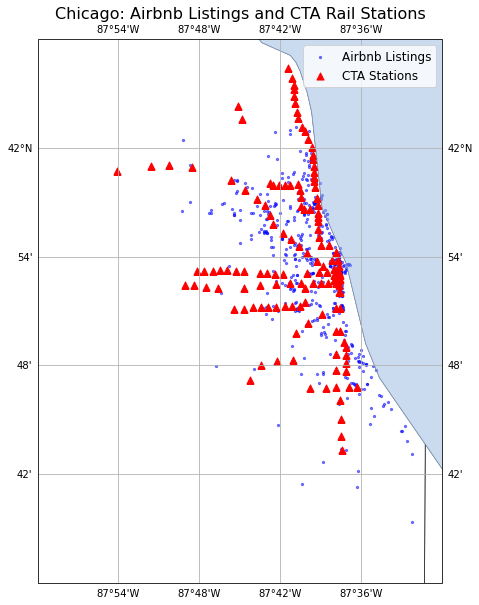

In [24]:
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-88.0, -87.5, 41.6, 42.1])

ax.add_feature(cf.COASTLINE, linewidth=0.5)
ax.add_feature(cf.STATES, linewidth=0.5)
ax.add_feature(cf.LAKES, alpha=0.5)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

sample_size = min(500, len(chicago_airbnb))
chicago_airbnb.sample(sample_size).plot(ax=ax, color='blue', markersize=5, 
                                        alpha=0.5, transform=ccrs.PlateCarree(),
                                        label='Airbnb Listings')

cta_stations.plot(ax=ax, color='red', markersize=50, marker='^', 
                  transform=ccrs.PlateCarree(), label='CTA Stations')

plt.title('Chicago: Airbnb Listings and CTA Rail Stations', fontsize=16)
plt.legend(fontsize=12)

plt.savefig('chicago_overview_map.png', dpi=300, bbox_inches='tight')
plt.show()

### Aribnb Distribution by Room Type

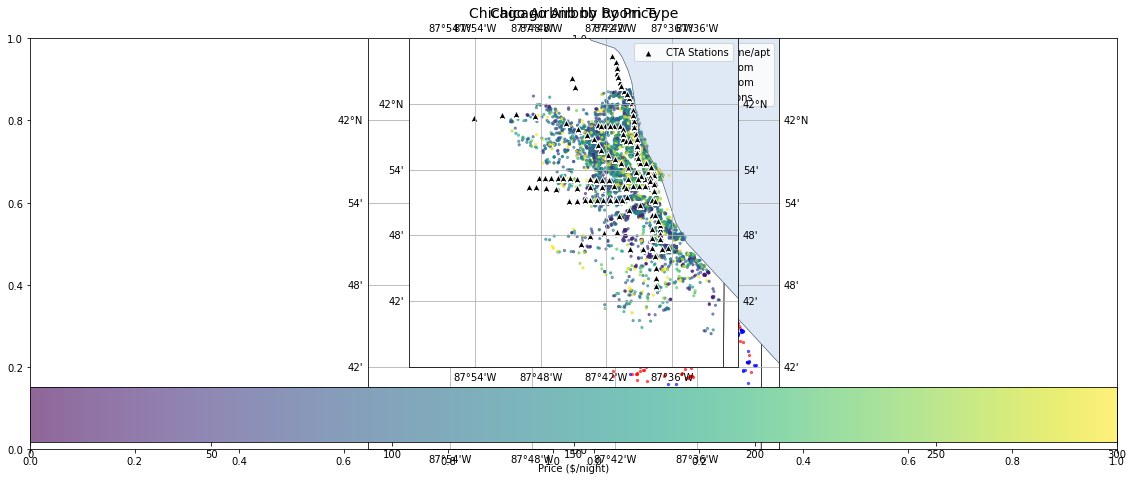

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
ax1 = plt.axes(projection=ccrs.PlateCarree())
ax1.set_extent([-88.0, -87.5, 41.6, 42.1])
ax1.add_feature(cf.COASTLINE, linewidth=0.5)
ax1.add_feature(cf.STATES, linewidth=0.5)
ax1.add_feature(cf.LAKES, alpha=0.3)

colors = {'Entire home/apt': 'red', 'Private room': 'blue', 'Shared room': 'green'}
for room_type, color in colors.items():
    if room_type in chicago_airbnb['room_type'].values:
        subset = chicago_airbnb[chicago_airbnb['room_type'] == room_type]
        ax1.scatter(subset['longitude'], subset['latitude'], 
                    c=color, label=room_type, s=5, alpha=0.6, transform=ccrs.PlateCarree())

ax1.scatter(cta_stations['geometry'].x, cta_stations['geometry'].y,
            c='black', marker='^', s=50, label='CTA Stations', 
            edgecolor='white', transform=ccrs.PlateCarree())

ax1.set_title('Chicago Airbnb by Room Type', fontsize=14)
ax1.legend(fontsize=10)
ax1.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

ax2 = axes[1]
ax2 = plt.axes(projection=ccrs.PlateCarree())
ax2.set_extent([-88.0, -87.5, 41.6, 42.1])
ax2.add_feature(cf.COASTLINE, linewidth=0.5)
ax2.add_feature(cf.STATES, linewidth=0.5)
ax2.add_feature(cf.LAKES, alpha=0.3)

sc = ax2.scatter(chicago_airbnb['longitude'], chicago_airbnb['latitude'],
                 c=chicago_airbnb['price'], cmap='viridis', 
                 s=5, alpha=0.6, transform=ccrs.PlateCarree(), vmin=0, vmax=300)

ax2.scatter(cta_stations['geometry'].x, cta_stations['geometry'].y,
            c='black', marker='^', s=50, label='CTA Stations', 
            edgecolor='white', transform=ccrs.PlateCarree())

plt.colorbar(sc, ax=ax2, label='Price ($/night)', orientation='horizontal', pad=0.05)
ax2.set_title('Chicago Airbnb by Price', fontsize=14)
ax2.legend(fontsize=10)
ax2.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

plt.tight_layout()
plt.savefig('airbnb_comparison_maps.png', dpi=300, bbox_inches='tight')
plt.show()

### Transit Buffer Zones

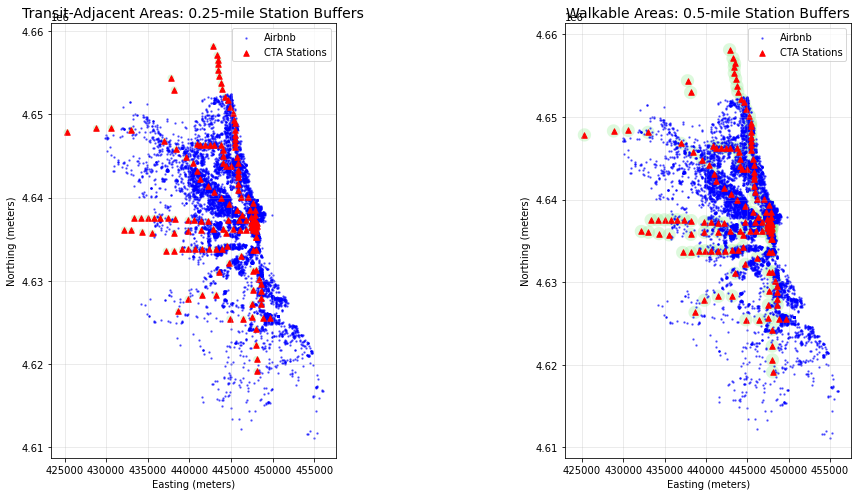

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
ax2 = axes[1]

buffer_025 = cta_stations_proj.copy()
buffer_025['geometry'] = buffer_025.geometry.buffer(402)  # 0.25 miles in meters

buffer_05 = cta_stations_proj.copy()
buffer_05['geometry'] = buffer_05.geometry.buffer(804)  # 0.5 miles in meters

buffer_025.plot(ax=ax1, color='lightgreen', alpha=0.3, edgecolor='none')
chicago_airbnb_proj.plot(ax=ax1, color='blue', markersize=2, alpha=0.5, label='Airbnb')
cta_stations_proj.plot(ax=ax1, color='red', markersize=30, marker='^', label='CTA Stations')
ax1.set_title('Transit-Adjacent Areas: 0.25-mile Station Buffers', fontsize=14)
ax1.set_xlabel('Easting (meters)')
ax1.set_ylabel('Northing (meters)')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

buffer_05.plot(ax=ax2, color='lightgreen', alpha=0.3, edgecolor='none')
chicago_airbnb_proj.plot(ax=ax2, color='blue', markersize=2, alpha=0.5, label='Airbnb')
cta_stations_proj.plot(ax=ax2, color='red', markersize=30, marker='^', label='CTA Stations')
ax2.set_title('Walkable Areas: 0.5-mile Station Buffers', fontsize=14)
ax2.set_xlabel('Easting (meters)')
ax2.set_ylabel('Northing (meters)')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transit_buffer_zones.png', dpi=300, bbox_inches='tight')
plt.show()

### Hotspot Density Map

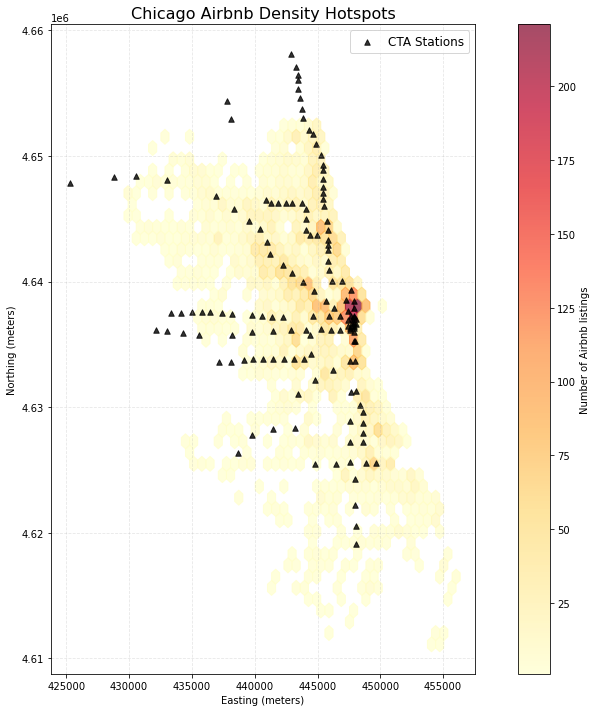

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

x = chicago_airbnb_proj.geometry.x
y = chicago_airbnb_proj.geometry.y

hb = ax.hexbin(x, y, gridsize=40, cmap='YlOrRd', alpha=0.7, mincnt=1)

cta_stations_proj.plot(ax=ax, color='black', markersize=30, marker='^', 
                       label='CTA Stations', alpha=0.8)

plt.colorbar(hb, ax=ax, label='Number of Airbnb listings')

ax.grid(True, alpha=0.3, linestyle='--')

ax.set_title('Chicago Airbnb Density Hotspots', fontsize=16)
ax.set_xlabel('Easting (meters)')
ax.set_ylabel('Northing (meters)')
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('airbnb_density_hotspots.png', dpi=300, bbox_inches='tight')
plt.show()

### Distance Distribution Histogram

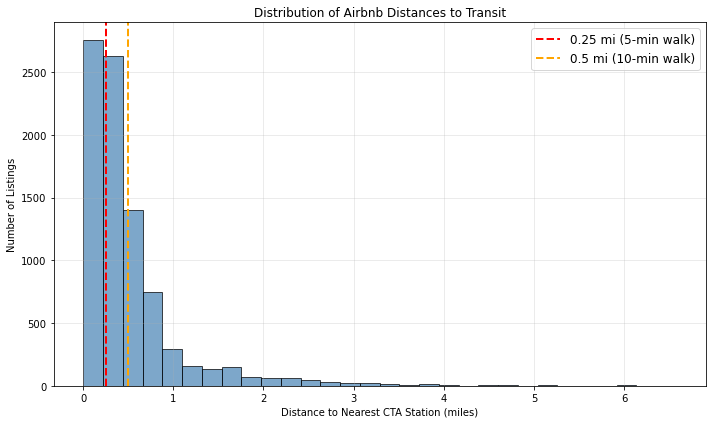

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(chicago_airbnb_proj['dist_to_station_mi'], bins=30, color='steelblue', 
        edgecolor='black', alpha=0.7)
ax.axvline(0.25, color='red', linestyle='--', linewidth=2, label='0.25 mi (5-min walk)')
ax.axvline(0.5, color='orange', linestyle='--', linewidth=2, label='0.5 mi (10-min walk)')
ax.set_xlabel('Distance to Nearest CTA Station (miles)')
ax.set_ylabel('Number of Listings')
ax.set_title('Distribution of Airbnb Distances to Transit')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distance_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

### Prive vs Distance Scateter Plot

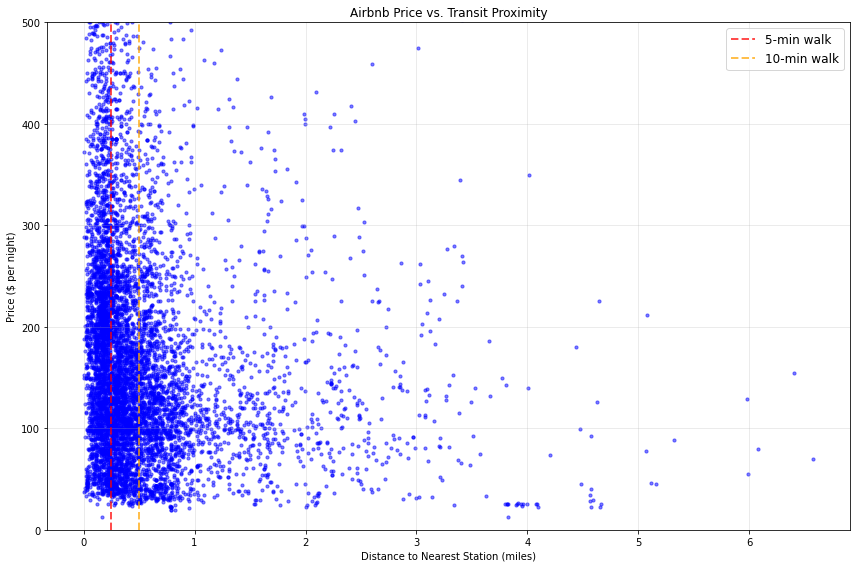

In [33]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(chicago_airbnb_proj['dist_to_station_mi'], chicago_airbnb_proj['price'], 
           alpha=0.5, c='blue', s=10)
ax.axvline(0.25, color='red', linestyle='--', alpha=0.7, linewidth=2, label='5-min walk')
ax.axvline(0.5, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='10-min walk')
ax.set_xlabel('Distance to Nearest Station (miles)')
ax.set_ylabel('Price ($ per night)')
ax.set_title('Airbnb Price vs. Transit Proximity')
ax.set_ylim(0, 500) 
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('price_vs_distance.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Concluding Discussion

This project demonstrates the spatial relationship between Airbnb listings and CTA rail transit in Chicago. The analysis reveals that over two-thirds (67.2%) of Airbnb properties are within a 10-minute walk of an "L" station, with a median distance of just 0.34 miles. Listings near transit command significantly higher prices, confirming that accessibility is highly valued in airbnb selections. The highest concentration of listings appears in downtown Chicago, where transit access is most convinient and dense. These findings suggest that public transportation infrastructure plays a crucial role in shaping the geography of airbnb rentals, with implications for urban planning, tourism, and housing policy.